# Anemia EDA — German Checkup Features Only

**Goal:** Explore anemia prediction using only features available in the German statutory health insurance 3-year checkup (Gesundheits-Check-up, §25 SGB V, for adults 35+).

**Allowed feature categories:**
- Lipid panel: total cholesterol, LDL, HDL, triglycerides
- Fasting blood glucose
- Urine dipstick: protein, glucose, erythrocytes, leukocytes, nitrite *(see availability note below)*
- Demographics: age, sex, BMI

**Dataset:** `nhanes_merged_adults_final.csv` — NHANES data, 7,437 adult participants

**Target:** `anemia` (binary: 1 = anemia diagnosis, 0 = no anemia)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

DATA_PATH = '../data/processed/nhanes_merged_adults_final.csv'

## 1. Load Data & Select Allowed Features

In [ ]:
# All columns we want — mapped to German checkup categories
FEATURE_MAP = {
    # Lipid panel
    'total_cholesterol_mg_dl':                   'Total Cholesterol (mg/dL)',
    'hdl_cholesterol_mg_dl':                     'HDL Cholesterol (mg/dL)',
    'LBDLDL_ldl_cholesterol_friedewald_mg_dl':   'LDL Cholesterol — Friedewald (mg/dL)',
    'triglycerides_mg_dl':                       'Triglycerides (mg/dL)',
    # Fasting glucose
    'fasting_glucose_mg_dl':                     'Fasting Blood Glucose (mg/dL)',
    # Demographics
    'age_years':                                 'Age (years)',
    'gender':                                    'Gender',
    'bmi':                                       'BMI (kg/m²)',
    # Target
    'anemia':                                    'Anemia (target)',
}

df_full = pd.read_csv(DATA_PATH, low_memory=False)
available = [c for c in FEATURE_MAP if c in df_full.columns]
missing_from_dataset = [c for c in FEATURE_MAP if c not in df_full.columns]

df = df_full[available].copy()

print(f'Full dataset shape: {df_full.shape}')
print(f'Checkup feature subset shape: {df.shape}')
print(f'\nFeatures loaded ({len(available)-1} features + target):')
for c in available:
    print(f'  {c}')

if missing_from_dataset:
    print(f'\n⚠️  Columns not found in dataset: {missing_from_dataset}')

## ⚠️ Data Availability Note: Urine Dipstick

**The German checkup includes urine dipstick analysis** (protein, glucose, erythrocytes, leukocytes, nitrite). However, **standard urine dipstick result columns are not present in this NHANES merged dataset.**

The dataset contains urine *quantitative* lab values (albumin/creatinine ratio `URDACT`, urine albumin `URXUMA`) but not the semi-quantitative dipstick result fields (typically `URXUPR`, `URXUGL`, `URXUCD`, etc. from NHANES `P_UA.xpt`).

**Decision:** Urine dipstick features are excluded from this analysis. This is noted as a limitation. If the raw XPT file `P_UA.xpt` is added to the pipeline, these features can be incorporated.

## 2. Target Variable Distribution

Anemia class distribution:
        count  percent
anemia                
0        7079    95.19
1         358     4.81


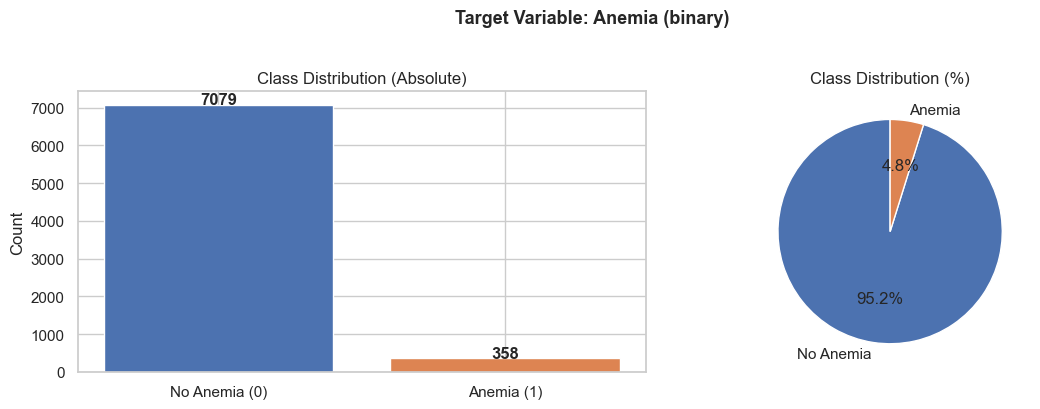


Class imbalance ratio: 19.8:1 (no anemia:anemia)


In [3]:
target_counts = df['anemia'].value_counts()
target_pct = df['anemia'].value_counts(normalize=True) * 100

print('Anemia class distribution:')
print(pd.DataFrame({'count': target_counts, 'percent': target_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Anemia (0)', 'Anemia (1)'], target_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Class Distribution (Absolute)')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['No Anemia', 'Anemia'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Target Variable: Anemia (binary)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nClass imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1 (no anemia:anemia)')

## 3. Missing Values Analysis

                                                                        label  missing_count  missing_pct
LBDLDL_ldl_cholesterol_friedewald_mg_dl  LDL Cholesterol — Friedewald (mg/dL)           4291         57.7
triglycerides_mg_dl                                     Triglycerides (mg/dL)           4262         57.3
fasting_glucose_mg_dl                           Fasting Blood Glucose (mg/dL)           4206         56.6
LBDHCI_hepatitis_c_antibody_confirmed              Hep C Antibody (confirmed)           1058         14.2
LBXHCR_hepatitis_c_rna                                              Hep C RNA           1049         14.1
total_cholesterol_mg_dl                             Total Cholesterol (mg/dL)           1019         13.7
hdl_cholesterol_mg_dl                                 HDL Cholesterol (mg/dL)           1019         13.7
LBXHBS_hepatitis_b_surface_antibody                    Hep B Surface Antibody            992         13.3
LBDHBG_hepatitis_b_surface_antigen            

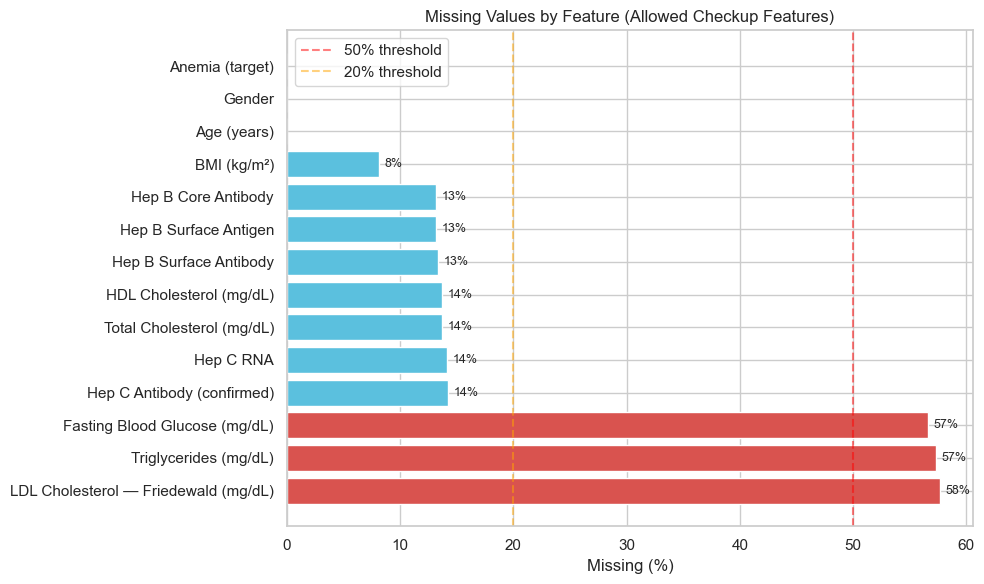

In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(1)
missing_df = pd.DataFrame({
    'label': [FEATURE_MAP.get(c, c) for c in df.columns],
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d9534f' if p > 50 else '#f0ad4e' if p > 20 else '#5bc0de' for p in missing_df['missing_pct']]
bars = ax.barh(missing_df['label'], missing_df['missing_pct'], color=colors, edgecolor='white')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.axvline(20, color='orange', linestyle='--', alpha=0.5, label='20% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Feature (Allowed Checkup Features)')
ax.legend()
for bar, val in zip(bars, missing_df['missing_pct']):
    if val > 0:
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Missing Values Commentary

| Feature group | Missing % | Reason |
|---|---|---|
| Fasting glucose, LDL, Triglycerides | ~57–58% | Fasting subsample only — NHANES only measured these on a subset of participants who fasted overnight |
| Total cholesterol, HDL | ~14% | Measurement subsample / random non-response |
| Age, Gender, BMI | 0–9% | Near-complete demographic data |

## 4. Distributions of Numeric Features

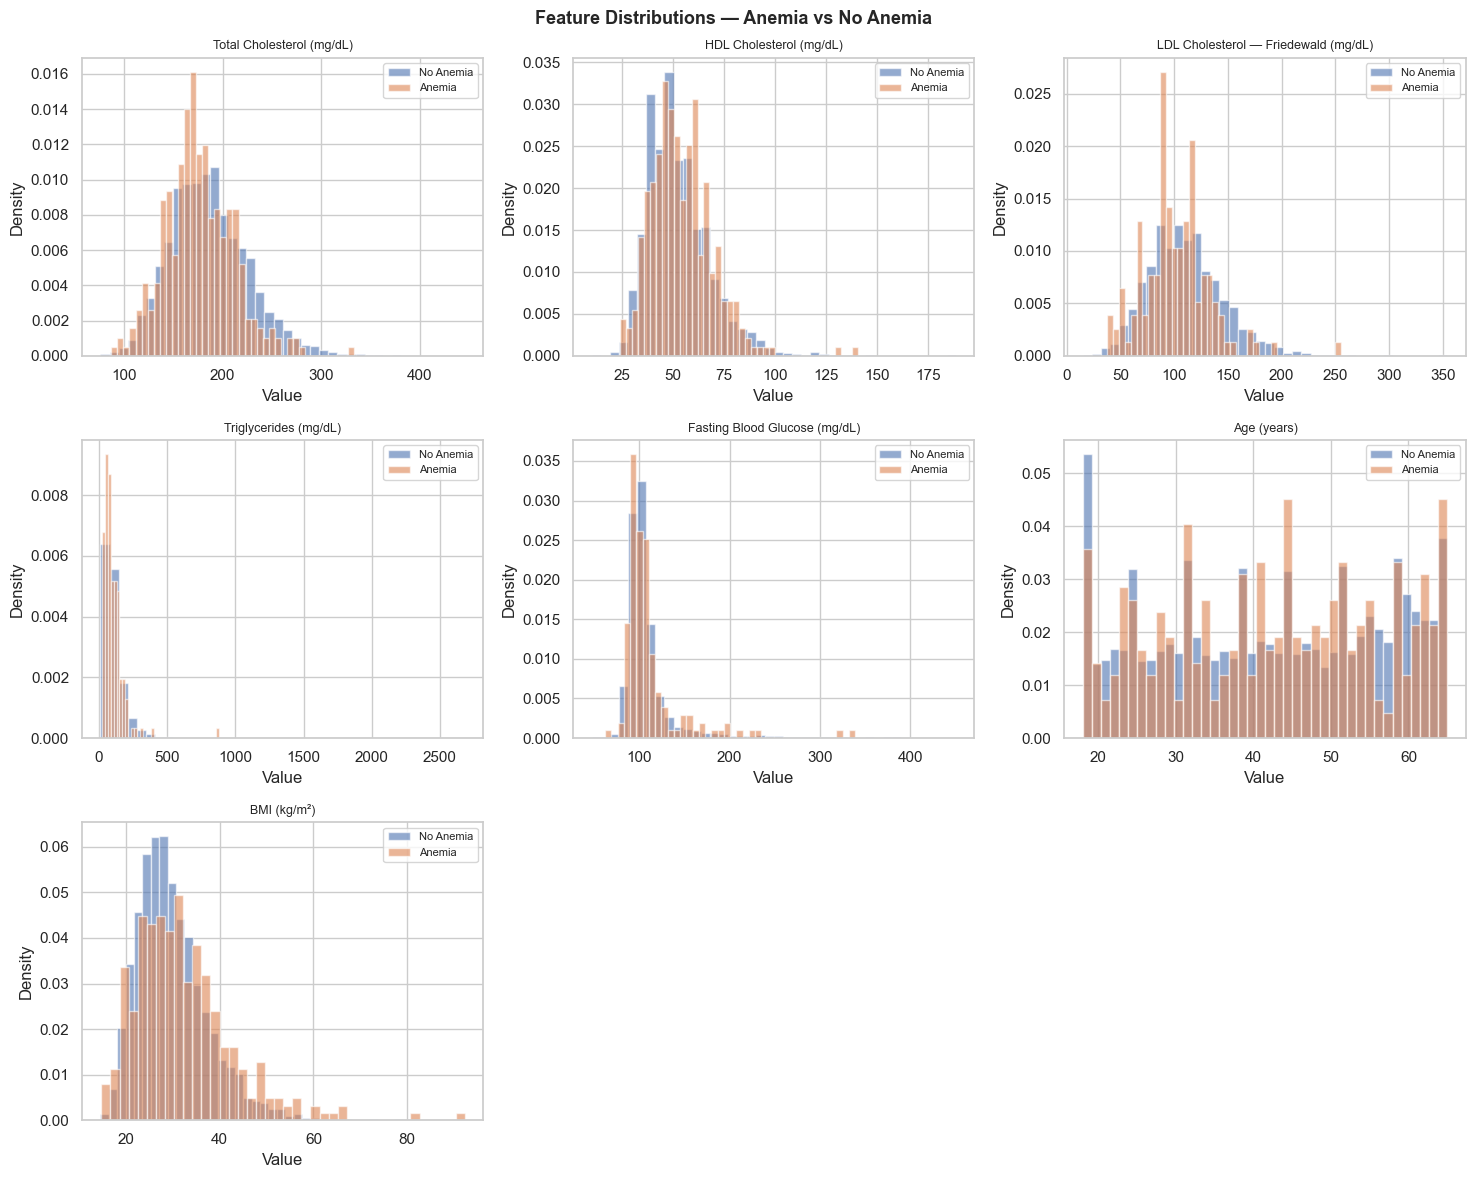

In [5]:
numeric_features = [
    'total_cholesterol_mg_dl', 'hdl_cholesterol_mg_dl',
    'LBDLDL_ldl_cholesterol_friedewald_mg_dl', 'triglycerides_mg_dl',
    'fasting_glucose_mg_dl', 'age_years', 'bmi'
]
num_labels = [FEATURE_MAP[c] for c in numeric_features]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(numeric_features, num_labels)):
    ax = axes[i]
    no_anemia = df.loc[df['anemia'] == 0, col].dropna()
    with_anemia = df.loc[df['anemia'] == 1, col].dropna()
    ax.hist(no_anemia, bins=40, alpha=0.6, color='#4C72B0', label='No Anemia', density=True)
    ax.hist(with_anemia, bins=40, alpha=0.6, color='#DD8452', label='Anemia', density=True)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions — Anemia vs No Anemia', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Anemia Prevalence by Gender & Age

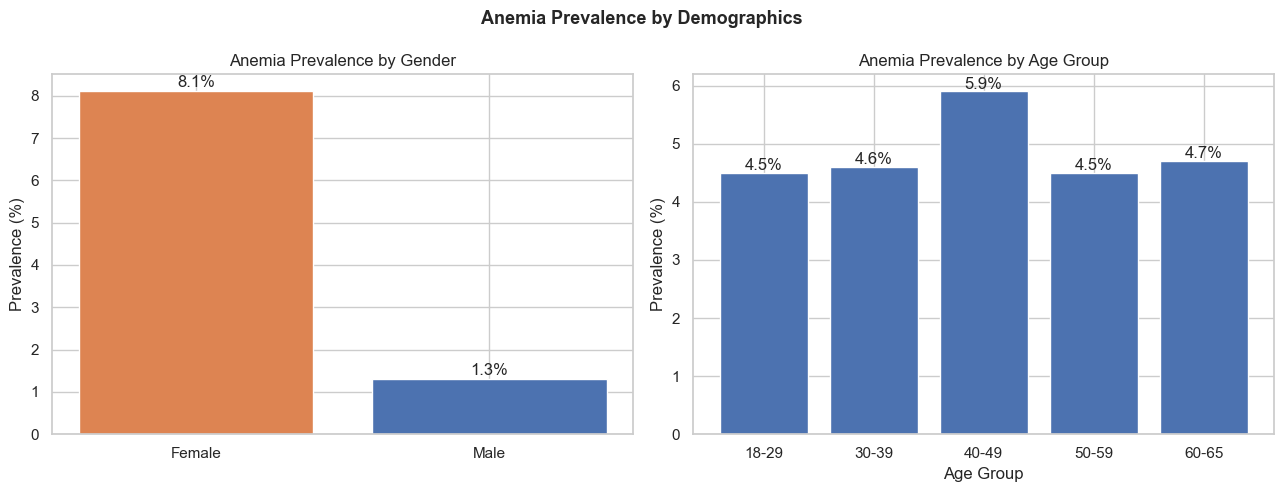

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# By gender
gender_anemia = df.groupby('gender')['anemia'].agg(['sum', 'count'])
gender_anemia['prevalence_pct'] = (gender_anemia['sum'] / gender_anemia['count'] * 100).round(1)
axes[0].bar(gender_anemia.index, gender_anemia['prevalence_pct'],
            color=['#DD8452', '#4C72B0'], edgecolor='white')
axes[0].set_title('Anemia Prevalence by Gender')
axes[0].set_ylabel('Prevalence (%)')
for i, (idx, row) in enumerate(gender_anemia.iterrows()):
    axes[0].text(i, row['prevalence_pct'] + 0.1, f"{row['prevalence_pct']}%", ha='center')

# By age group
df['age_group'] = pd.cut(df['age_years'], bins=[17, 29, 39, 49, 59, 65],
                          labels=['18-29', '30-39', '40-49', '50-59', '60-65'])
age_anemia = df.groupby('age_group', observed=True)['anemia'].agg(['sum', 'count'])
age_anemia['prevalence_pct'] = (age_anemia['sum'] / age_anemia['count'] * 100).round(1)
axes[1].bar(age_anemia.index.astype(str), age_anemia['prevalence_pct'],
            color='#4C72B0', edgecolor='white')
axes[1].set_title('Anemia Prevalence by Age Group')
axes[1].set_ylabel('Prevalence (%)')
axes[1].set_xlabel('Age Group')
for i, (idx, row) in enumerate(age_anemia.iterrows()):
    axes[1].text(i, row['prevalence_pct'] + 0.05, f"{row['prevalence_pct']}%", ha='center')

df.drop(columns=['age_group'], inplace=True)
plt.suptitle('Anemia Prevalence by Demographics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Correlation of Numeric Features with Anemia Target

Point-Biserial Correlation with Anemia Target:
                             feature                                  column    n    corr  pvalue significant
                         BMI (kg/m²)                                     bmi 6833  0.0618  0.0000           ✓
LDL Cholesterol — Friedewald (mg/dL) LBDLDL_ldl_cholesterol_friedewald_mg_dl 3146 -0.0556  0.0018           ✓
           Total Cholesterol (mg/dL)                 total_cholesterol_mg_dl 6418 -0.0544  0.0000           ✓
             HDL Cholesterol (mg/dL)                   hdl_cholesterol_mg_dl 6418  0.0201  0.1082            
               Triglycerides (mg/dL)                     triglycerides_mg_dl 3175 -0.0146  0.4117            
       Fasting Blood Glucose (mg/dL)                   fasting_glucose_mg_dl 3231  0.0095  0.5879            
                         Age (years)                               age_years 7437  0.0065  0.5743            


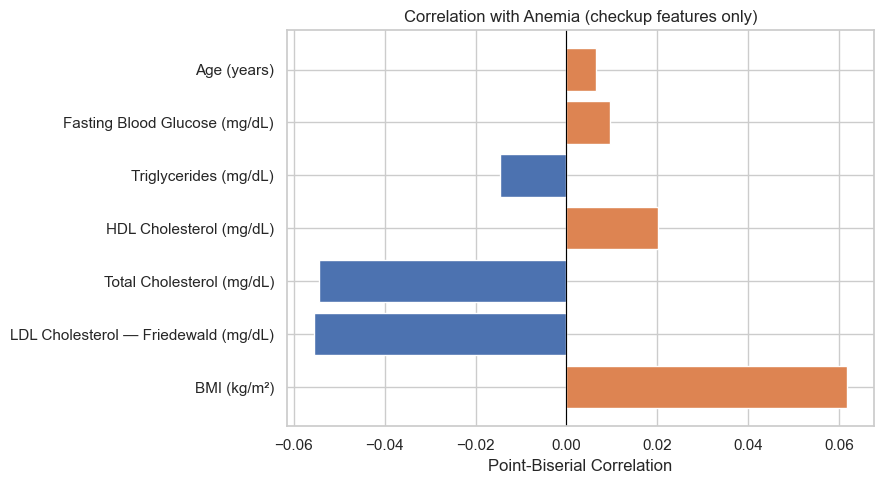

In [7]:
from scipy.stats import pointbiserialr

corr_results = []
for col in numeric_features:
    valid = df[['anemia', col]].dropna()
    if len(valid) > 30:
        r, p = pointbiserialr(valid['anemia'], valid[col])
        corr_results.append({
            'feature': FEATURE_MAP[col],
            'column': col,
            'n': len(valid),
            'corr': round(r, 4),
            'pvalue': round(p, 4),
            'significant': '✓' if p < 0.05 else ''
        })

corr_df = pd.DataFrame(corr_results).sort_values('corr', key=abs, ascending=False)
print('Point-Biserial Correlation with Anemia Target:')
print(corr_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in corr_df['corr']]
ax.barh(corr_df['feature'], corr_df['corr'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation')
ax.set_title('Correlation with Anemia (checkup features only)')
plt.tight_layout()
plt.show()

## 7. Feature-by-Feature Boxplots (Anemia vs No Anemia)

C:\Users\Inbal\AppData\Local\Temp\ipykernel_26568\1878614579.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['No Anemia', 'Anemia'], patch_artist=True,
C:\Users\Inbal\AppData\Local\Temp\ipykernel_26568\1878614579.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['No Anemia', 'Anemia'], patch_artist=True,
C:\Users\Inbal\AppData\Local\Temp\ipykernel_26568\1878614579.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['No Anemia', 'Anemia'], patch_artist=True,
C:\Users\Inbal\AppData\Local\Temp\ipykernel_26568\1878614579.

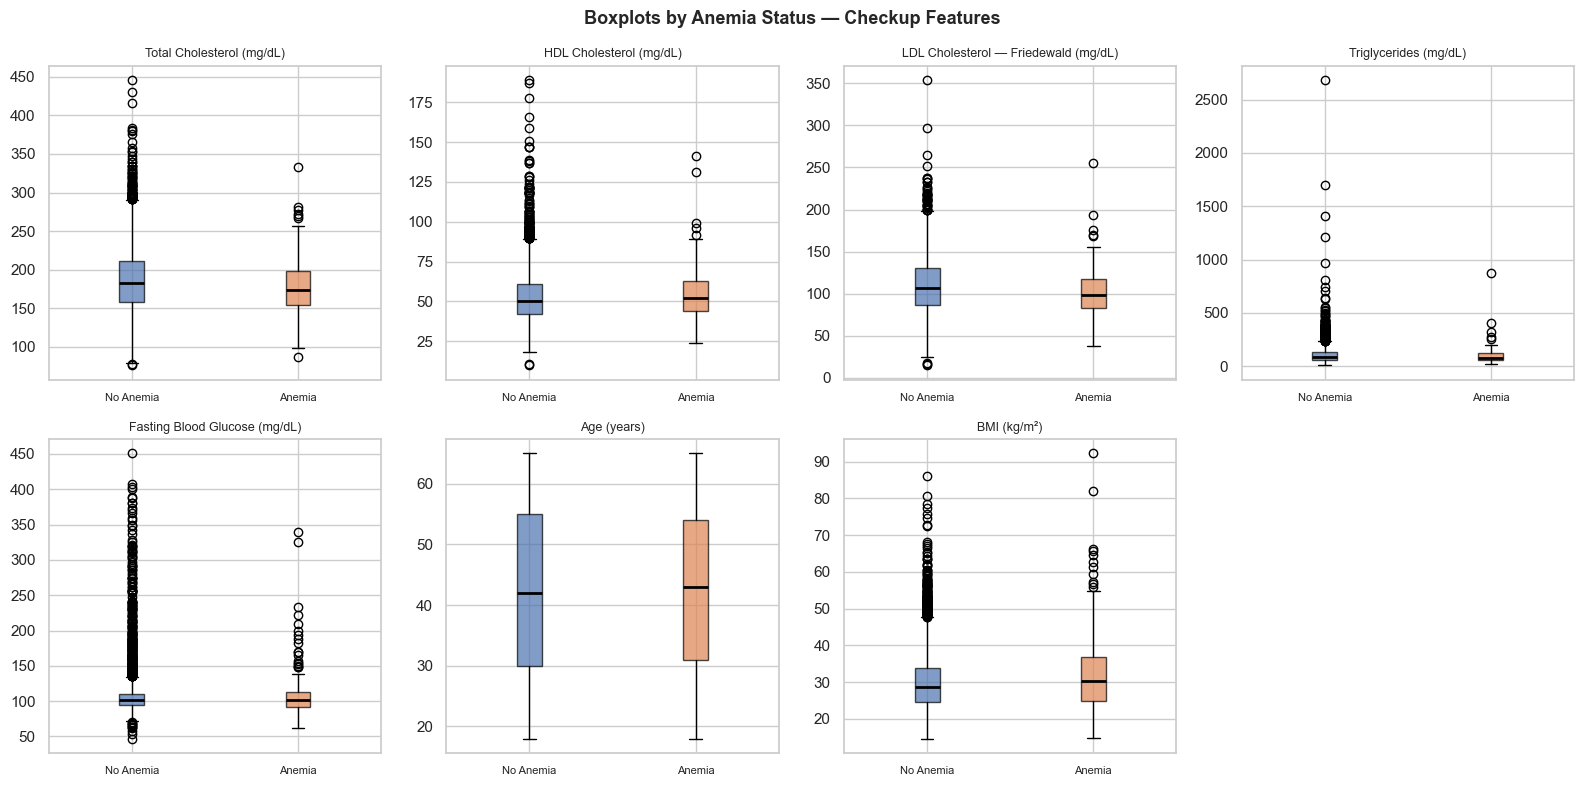

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(numeric_features, num_labels)):
    ax = axes[i]
    plot_data = df[['anemia', col]].dropna()
    groups = [plot_data.loc[plot_data['anemia'] == 0, col],
              plot_data.loc[plot_data['anemia'] == 1, col]]
    bp = ax.boxplot(groups, labels=['No Anemia', 'Anemia'], patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#DD8452')
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(label, fontsize=9)
    ax.tick_params(axis='x', labelsize=8)

for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots by Anemia Status — Checkup Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Correlation Heatmap (Numeric Features)

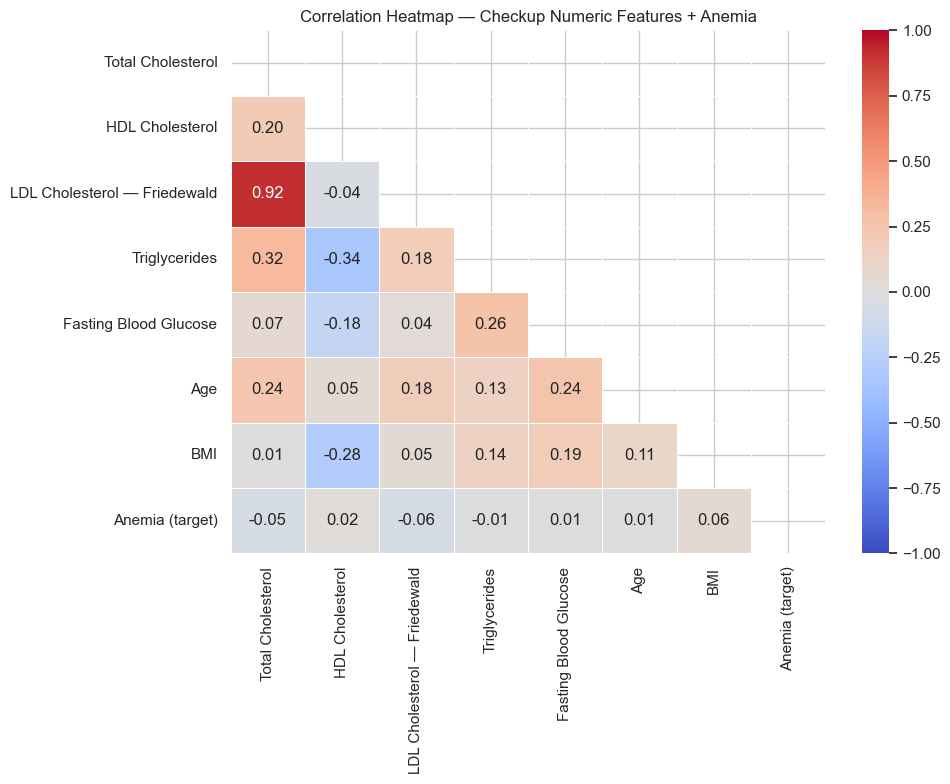

In [10]:
heatmap_cols = numeric_features + ['anemia']
heatmap_labels = [FEATURE_MAP[c].replace(' (mg/dL)', '').replace(' (kg/m²)', '').replace(' (years)', '') 
                  for c in heatmap_cols]

corr_matrix = df[heatmap_cols].corr()
corr_matrix.index = heatmap_labels
corr_matrix.columns = heatmap_labels

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Checkup Numeric Features + Anemia', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Summary & Feature Readiness

| Feature | Available | Missing % | Notes |
|---|---|---|---|
| Total Cholesterol | ✅ | ~14% | Impute with median |
| HDL Cholesterol | ✅ | ~14% | Impute with median |
| LDL Cholesterol | ✅ | ~58% | Fasting subsample; impute with median — flag limitation |
| Triglycerides | ✅ | ~58% | Fasting subsample; impute with median — flag limitation |
| Fasting Glucose | ✅ | ~57% | Fasting subsample; impute with median — flag limitation |
| Age | ✅ | 0% | Ready |
| Gender | ✅ | 0% | Encode: Female=1, Male=0 |
| BMI | ✅ | ~9% | Impute with median |
| **Urine Dipstick** | ❌ | N/A | **Not available in this dataset** — NHANES `P_UA.xpt` not ingested |

**Total usable features: 8**  
**Class imbalance:** ~20:1 → use `class_weight='balanced'` or SMOTE in model training